In [1]:
from mpasviewer import scvtmesh
from earthcmap import escmap
import cartopy.crs as ccrs

In [2]:
path2data = 'sample_data'

mpasd = scvtmesh(grid_file=f'{path2data}/MPAS_CHEM/invariant.send.nc', 
                 diag_list=f'{path2data}/MPAS_CHEM/out/cheMPAS-Fire_pm25.2026-02-09_18.00.00.nc')

In [ ]:
mpasd.dataset()

In [4]:
dta = mpasd.load()

In [5]:
dta

<xarray.Dataset> Size: 778MB
Dimensions:                      (node: 4689840, edge: 7031657, face: 2341818,
                                  time: 1, nVertLevels: 59, nmax_face: 6)
Coordinates:
    node_x                       (node) float32 19MB -110.9 -111.0 ... -89.92
    node_y                       (node) float32 19MB 29.99 29.99 ... 40.47 40.46
    edge_x                       (edge) float32 28MB -110.9 -110.9 ... -89.93
    edge_y                       (edge) float32 28MB 29.99 29.99 ... 40.48 40.47
    face_x                       (face) float32 9MB -110.9 -110.9 ... -89.96
    face_y                       (face) float32 9MB 30.0 30.0 ... 40.5 40.48
  * time                         (time) datetime64[ns] 8B 2026-02-09T18:00:00
  * nVertLevels                  (nVertLevels) int64 472B 0 1 2 3 ... 56 57 58
Dimensions without coordinates: node, edge, face, nmax_face
Data variables:
    mesh2d                       int64 8B 0
    projected_coordinate_system  int64 8B 0
    face_nodes                   (face, nmax_face) int64 112MB 127 ... 4689828
    PM2_5                        (time, nVertLevels, face) float32 553MB 0.00...
Attributes:
    Conventions:      CF-1.12 UGRID-1.0
    model_name:       MPAS
    core_name:        Atmosphere
    source:           MPAS-A
    source_software:  MPAS-viewer
    date_created:     2026-02-20 00:48:51Z
    date_modified:    2026-02-20 00:48:51Z

In [6]:
times = [str(x) for x in dta['time'].data.astype('datetime64[s]')]
# print(*times, sep = ", ")

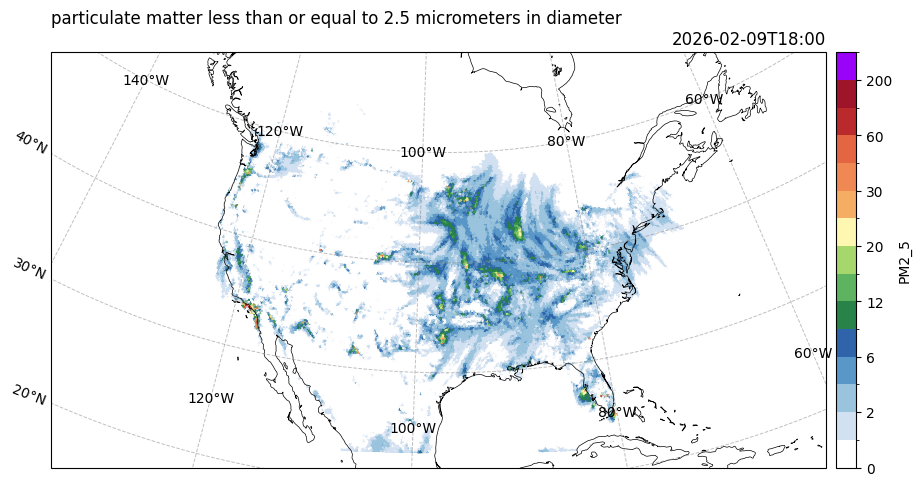

In [7]:
var1 = 'PM2_5'
cmap, norm = escmap("smoke")
mpasd.show(dta, var_name = var1, level=0, crs=ccrs.LambertConformal(central_longitude=-96.8, central_latitude=38.2), cmap = cmap, norm = norm, figsize = (10, 10))